In [1]:
%run 10_MNESIS_polychronous-chains.ipynb
# overwrite some global variables locally
figpath = Path('../figures')
# HACK
RECOMPUTE = True

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


## defining traveling waves patterns



In [2]:
# opt = Params(N_neuron=64**2) # TODO launch a run on GAIA with this setting, but it takes a long time to compute
# opt = Params(N_neuron=42**2)
opt = Params(N_neuron=32**2, do_pinv=True)
# opt = Params(N_neuron=32**2, do_pinv=False)
hd = HD_SNN(opt, SpikingPattern)
hd.target().shape, opt.N_neuron, opt.N_time

(torch.Size([16, 1024, 1000]), 1024, 1000)

In [ ]:
import MotionClouds as mc
N_X = int(opt.N_neuron**.5)

movie_gain = 20.
movie_gain = 5.
movie_gain = 10.
v = 1.
v = .2

def get_TW(angle, v=v):
    # define Fourier domain
    mc.N_X, mc.N_Y, mc.N_frame = N_X, N_X, opt.N_time//2 # HACK : half the length to make it periodic
    fx, fy, ft = mc.get_grids(mc.N_X, mc.N_Y, mc.N_frame)
    # define an envelope
    envelope = mc.envelope_gabor(fx, fy, ft,
        V_X=v*np.cos(angle), V_Y=v*np.sin(angle), B_V=.1,
        sf_0=.05, B_sf=.025,
        # sf_0=.10, B_sf=.10,
        theta=angle, B_theta=np.pi/8
        )    

    movie = mc.random_cloud(envelope, seed=opt.seed)
    movie = mc.rectif(movie)
    movie = (2*movie - 1)
    return torch.Tensor(movie)

movie = get_TW(angle=np.pi/4, v=.5)
movie.min(), movie.max()

(tensor(-0.847), tensor(1.))

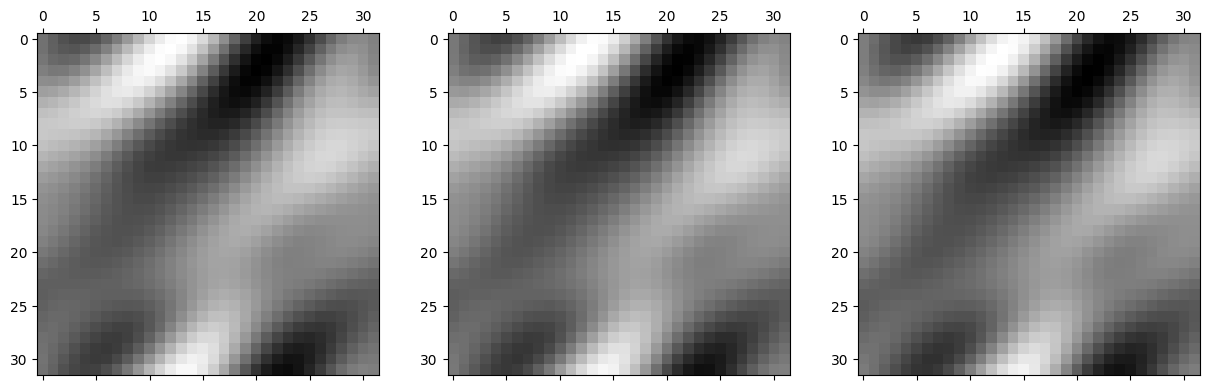

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(movie[:, :, i_ax], cmap='gray')

In [5]:
def get_TW_spike(angle, movie_gain=movie_gain, p_A=opt.p_A):
    movie = get_TW(angle)
    A_proba = torch.sigmoid(torch.logit(torch.tensor(p_A)) + movie_gain * movie) 
    # TODO : use a LIF instead with a proper reset / refractory mechanism, but for now this is a simple way to get a binary pattern with the same mean activity as the target pattern
    return torch.bernoulli(A_proba)

A = get_TW_spike(angle=0.)
A.shape, A.mean()

(torch.Size([32, 32, 500]), tensor(0.020))

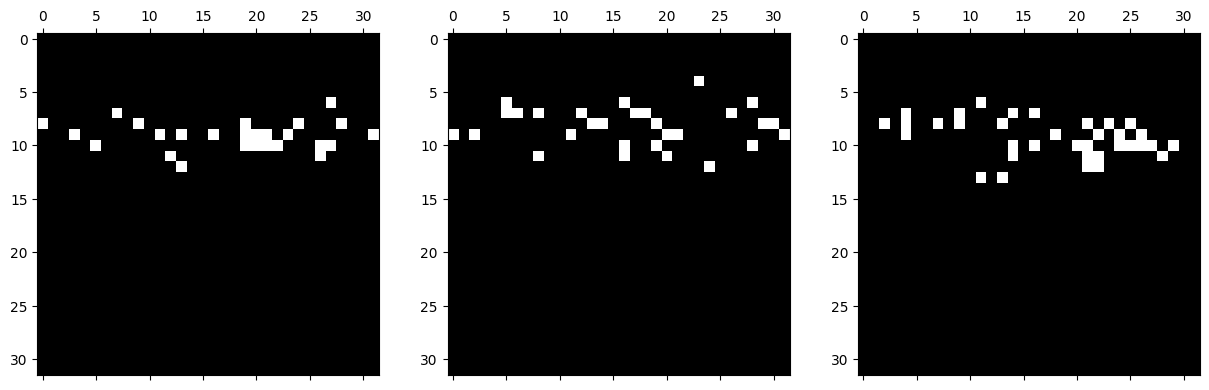

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(A[:, :, i_ax], cmap='gray')

In [7]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    im = ax.imshow(A[:, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        im.set_array(A[:, :, frame])
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=movie.shape[2],
        interval=40, # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'TW.mp4', writer='ffmpeg', fps=25)
    plt.close()

## learning traveling waves patterns

In [8]:
# opt = Params()
# hd = HD_SNN(opt)
# hd.net.to(hd.opt.device)

# Make the target periodic
target = hd.target()
for j_SM, angle in enumerate(np.linspace(0, 2*np.pi, opt.N_pattern, endpoint=False)):
    TW = get_TW_spike(angle=angle).repeat(1, 1, 2) # HACK repeat twice - not to use if we learn periodic patterns
    target[j_SM, :, :] = TW.reshape((opt.N_neuron, opt.N_time))
target.shape

torch.Size([16, 1024, 1000])

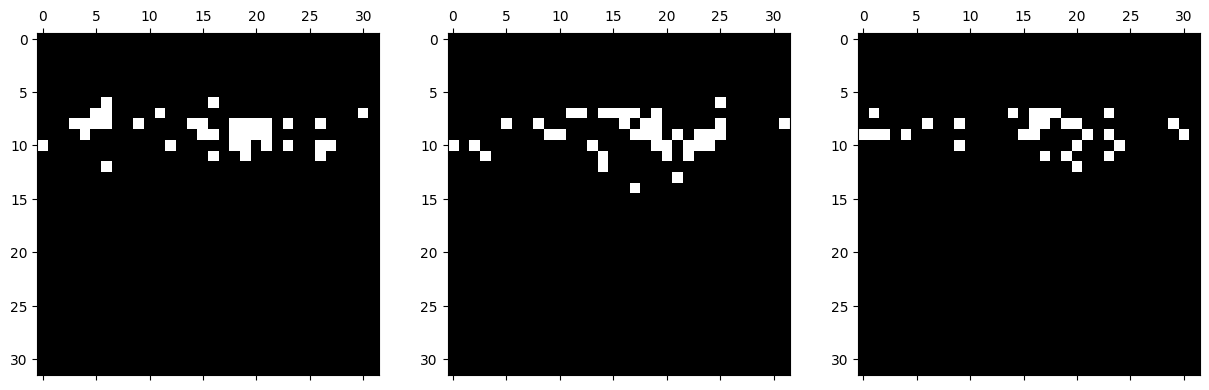

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(target[i_pattern, :,  i_ax].cpu().reshape((N_X, N_X)), cmap='gray')

In [10]:
model_filename = data_cache / f"{hd.opt.datetag}_TW.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-04-21_TW.pth, intitializing the new model.


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_98746/863181027.py:159: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  X_pinv = torch.linalg.pinv(contexts)            # (N_neuron*D, batch)


Train Epoch [000001/000016]	| Loss = 8.833e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000002/000016]	| Loss = 8.834e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000003/000016]	| Loss = 8.834e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000004/000016]	| Loss = 8.833e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000005/000016]	| Loss = 8.833e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000006/000016]	| Loss = 8.835e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000007/000016]	| Loss = 8.834e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000008/000016]	| Loss = 8.833e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000009/000016]	| Loss = 8.834e-01	| precision = 1.000	| recall = 0.062	| f1_score = 0.117	| 
Train Epoch [000010/000016]	| Loss = 8.834e-01

In [11]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 0.062	 f1_score = 0.117 


(torch.Size([16, 1024, 1100]), 4107.0, 20698.0)

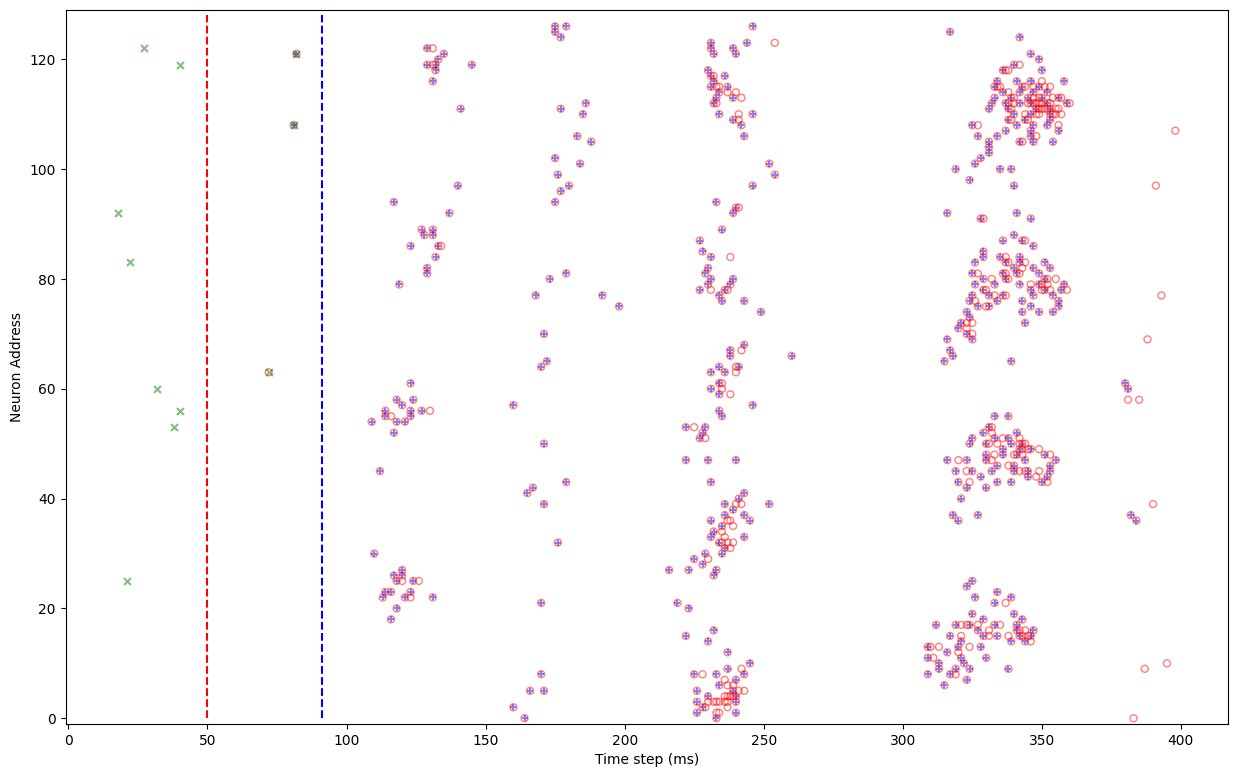

In [12]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

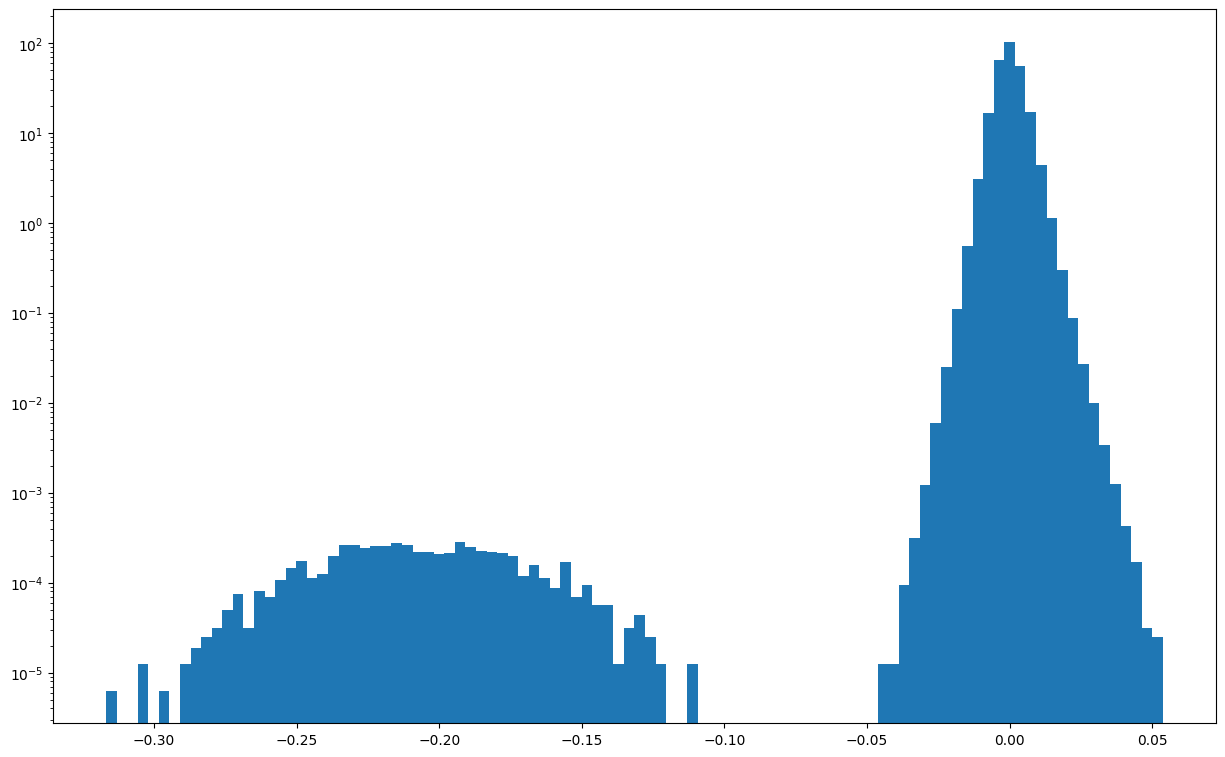

In [13]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')

## a long traveling wave

In [14]:
N_repeat = 10

with torch.no_grad():
    target_full = torch.nn.functional.pad(target.repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 0.006	 f1_score = 0.012 


(torch.Size([16, 1024, 10100]), 4109.0, 20698.0)

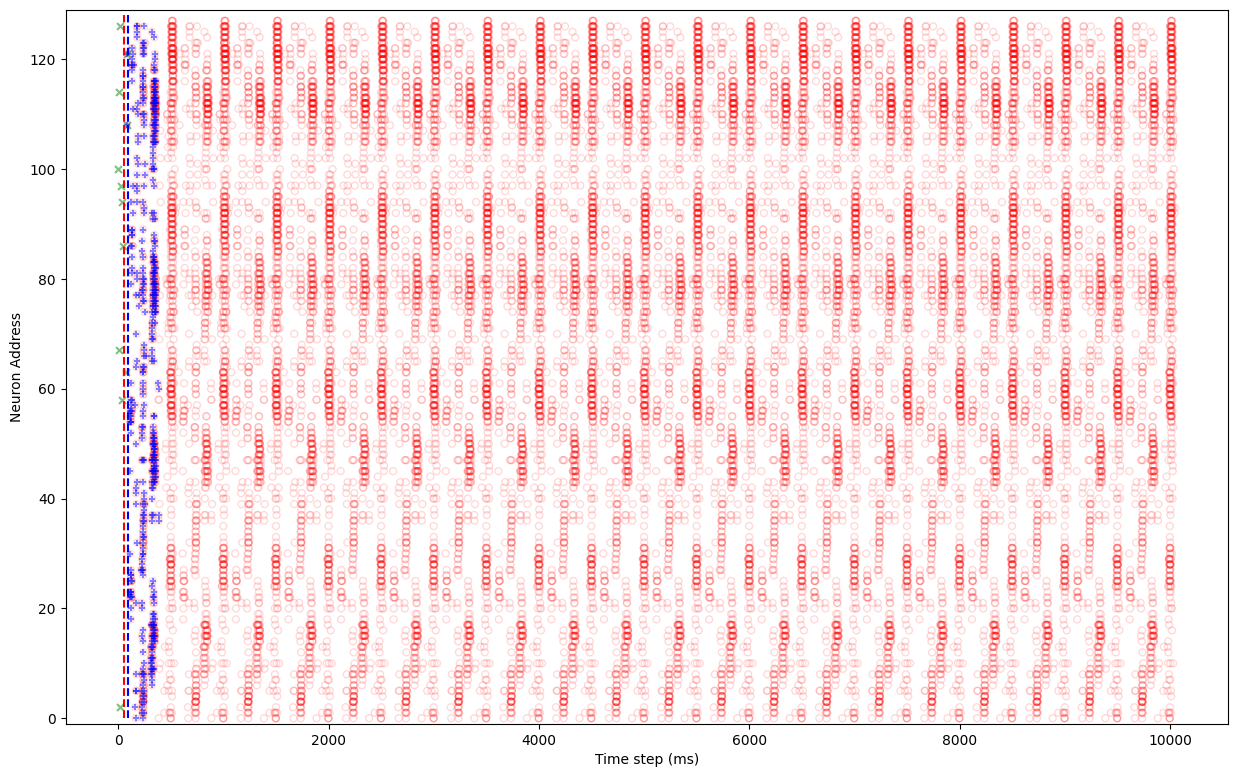

In [15]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.15)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

In [16]:
opt.lif_threshold

0.8

## a long traveling wave with different patterns

In [17]:
with torch.no_grad():
    N_iti_time = 10 #opt.N_pretime # * 4
    # N_stop = 10 #opt.num_delay
    target_full = torch.nn.functional.pad(target, (N_iti_time, N_iti_time))
    target_full = target_full.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))

    mask = torch.ones((opt.N_pattern, opt.N_neuron, opt.N_time), device=target_full.device)
    mask[:, :, opt.num_delay:] *= 0
    # mask[:, :, opt.num_delay:(-2*opt.num_delay)] *= 0
    mask = torch.nn.functional.pad(mask, (N_iti_time, N_iti_time))
    mask = mask.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))
    

    # shunt = torch.ones((opt.N_pattern, opt.N_neuron, opt.N_time), device=target_full.device)
    p_shunt = opt.p_A
    p_shunt = .115
    p_shunt = .15
    shunt = torch.bernoulli(p_shunt * torch.ones((opt.N_pattern, opt.N_neuron, opt.N_time), device=target_full.device))
    shunt[:, :, :(-opt.num_delay)] *= 0
    shunt = torch.nn.functional.pad(shunt, (N_iti_time, N_iti_time))
    shunt = shunt.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_pattern*(opt.N_time+2*N_iti_time)))
    
    ##################        
    input_spikes = (target_full * mask + shunt).unsqueeze(0)
    # input_spikes = flip_bits(input_spikes, p_flip)
    _, _, spikes = hd.forward_pass(input_spikes.to(opt.device))
    spikes = spikes.squeeze(0)
    ##################        

In [18]:
# target.shape, target[:, :-N_stop].shape, spikes.shape, target_full.shape, opt.N_pattern*(opt.N_time-N_stop+2*N_iti_time)

(torch.Size([1024, 16320]), torch.Size([1024, 16320]))

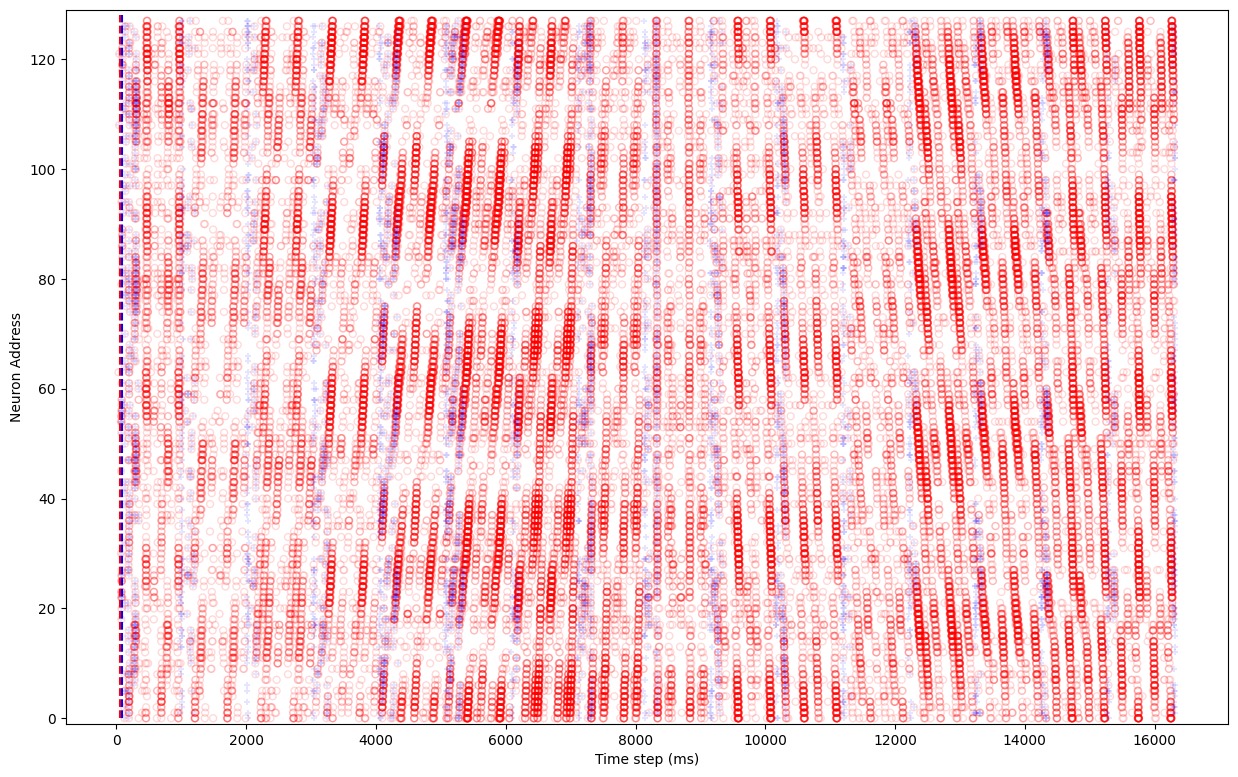

In [19]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[ :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.15)
# splt.raster(input_spikes[:opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
splt.raster(spikes[:opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.1)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, target_full.shape

(torch.Size([1024, 16320]), torch.Size([1024, 16320]))

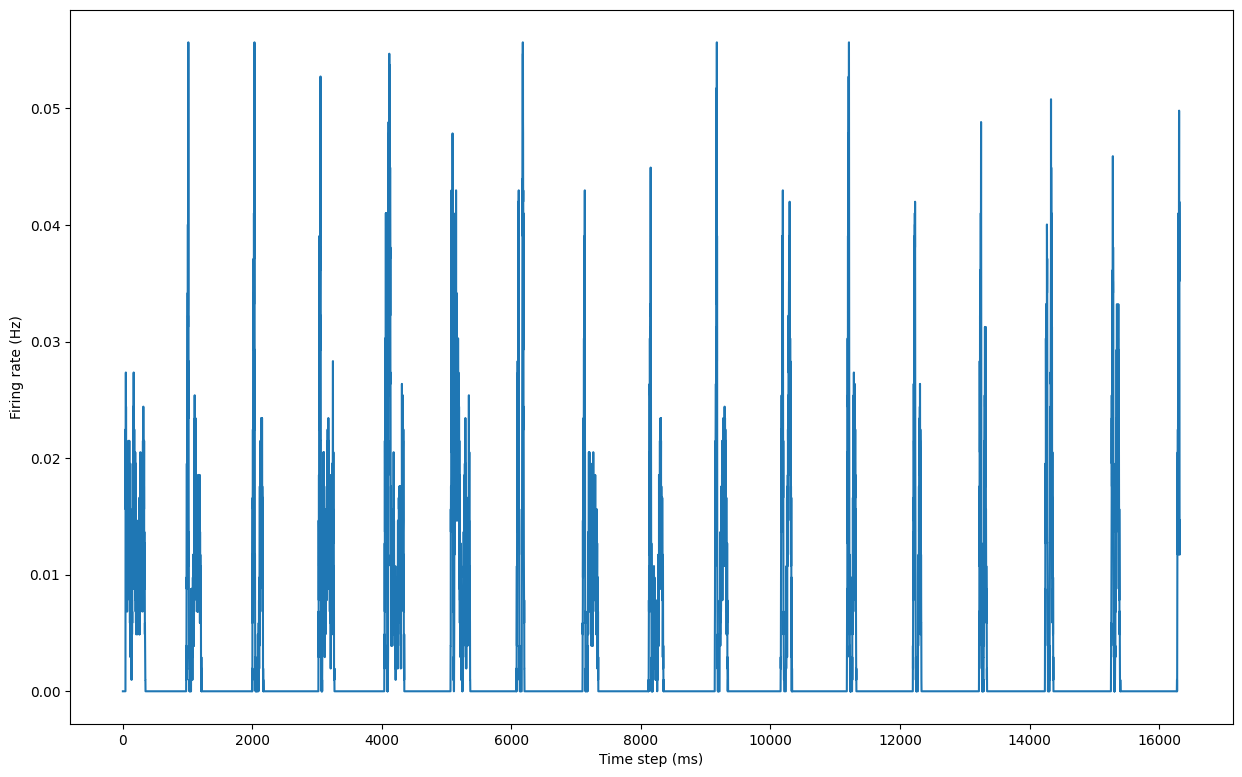

In [20]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.plot(spikes.mean(dim=0).cpu())
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Firing rate (Hz)")
spikes.shape, target_full.shape

TODO : the signal is periodic and never ends - how do I stop a memory ?

In [21]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    frame = 0
    colored_spikes = torch.zeros((N_X, N_X, 3))
    colored_spikes[:, :, 0] = spikes[:, frame].reshape((N_X, N_X))
    colored_spikes[:, :, 1] = input_spikes[0, :, frame].reshape((N_X, N_X))

    im = ax.imshow(colored_spikes, vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        colored_spikes = torch.zeros((N_X, N_X, 3))
        colored_spikes[:, :, 0] = spikes[:, frame].reshape((N_X, N_X))
        colored_spikes[:, :, 1] = input_spikes[0, :, frame].reshape((N_X, N_X))
        im.set_array(colored_spikes)
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=spikes.shape[-1],
        interval=20, # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    anim.save(figpath / 'TW_spikes.mp4', writer='ffmpeg', fps=50)
    plt.close()

## scanning parameters

In [ ]:
# opt_scan = Params(datetag = datetag + '_TW_scan',
#                   fig_width = 3.25,
#                   )

# N_scanning = 13 

# scan_dicts= {'N_pattern' : np.linspace(1, 30, N_scanning, dtype=int), # [2, 3, 5, 8, 13, 21], #, 34, 55, 89, 144, 233, 377, 610, 987, 1364, 2351
#              'N_time' : np.geomspace(100, 3000, N_scanning, dtype=int), #[2**k for k in range(6, 12)],
#              'num_delay' : np.linspace(1, 60, N_scanning, dtype=int), # [2, 3, 5, 8, 13, 21, 34, 55, 89],
#              'N_neuron' : np.geomspace(50, 2000, N_scanning, dtype=int), # [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
#              'p_A': np.geomspace(0.0002, 0.05, N_scanning, dtype=float) , # [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
#              'do_deconv' : [True, False],
#              'do_pinv' : [True, False],
#             }
# label_dicts= {'N_pattern' : 'number of patterns',
#              'N_time' : 'Pattern duration',
#              'num_delay' : 'Delay range',
#              'N_neuron' : 'Presynaptic inputs',
#              'p_A': 'Average firing',
#              'do_deconv' : 'Membrane deconvolution',
#              'do_pinv' : 'Full pseudo-inverse computation',
#             }
# import time
# import pandas as pd

# N_cv = 10
# N_cv = 2

# verb = True

# for key in scan_dicts:
#     print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
#     filename = data_cache / f'{opt_scan.datetag}_{key}.json'
#     lock_filename = data_cache / filename.with_suffix('.lock')
#     if RECOMPUTE : 
#         filename.unlink(missing_ok=True) # FORCING RECOMPUTE
#         lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

#     if not lock_filename.exists():
#         if filename.exists():
#             df_scan = pd.read_json(filename, orient='records')
#         else:
#             lock_filename.touch(exist_ok=True)
#             measure_columns = [key, 'loss', 'time']
#             df_scan = pd.DataFrame([], columns=measure_columns)
#             i_loc = 0
#             for i_value, value in enumerate(scan_dicts[key]):
#                 if verb: print('|', i_value + 1, '/', len(scan_dicts[key]), end='\t')

#                 for i_cv in  range(N_cv):
#                     # tic
#                     since = time.time()
#                     new_dict = asdict(opt)
#                     # print(key, value)
#                     new_dict[key] = value
#                     new_opt = Params(**new_dict)

#                     new_hd = HD_SNN(new_opt, SpikingPattern)
         
#                     new_hd.update_weight()
#                     new_hd.learn_model(verbose=False)

#                     # test it
#                     with torch.no_grad():
#                         input_spikes = new_hd.get_input_spikes(p_A=new_hd.opt.p_A, N_pretime=new_hd.opt.N_pretime, N_trigger_time=new_hd.opt.num_delay, N_time=new_hd.opt.N_time)
#                         _, _, spikes = new_hd.forward_pass(input_spikes)
#                         spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
#                         target_ = new_hd.target()[:, :, new_hd.opt.num_delay:]
#                         loss_val = loss_fn(spikes_, target_)
                                            
#                     # toc
#                     elapsed_time = time.time() - since
#                     df_scan.loc[i_loc] = {key:value, 'loss':loss_val.item(), 'time':elapsed_time}
#                     i_loc += 1
#                     if verb: 
#                         print(f'|{key=}:{value=} \t| loss={loss_val.item():.3f}', end='\t')
#                         print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

#             df_scan.to_json(filename, orient='records', indent=2)
#         lock_filename.unlink(missing_ok=True)
#         # print(df_scan)


--------------------------------------------------
scanning key='N_pattern'
--------------------------------------------------
--------------------------------------------------
scanning key='N_time'
--------------------------------------------------
--------------------------------------------------
scanning key='num_delay'
--------------------------------------------------
--------------------------------------------------
scanning key='N_neuron'
--------------------------------------------------
--------------------------------------------------
scanning key='p_A'
--------------------------------------------------
--------------------------------------------------
scanning key='do_deconv'
--------------------------------------------------
--------------------------------------------------
scanning key='do_pinv'
--------------------------------------------------


In [22]:
# from matplotlib import ticker
# subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
# custom_style = {
#     'axes.spines.left': True,
#     'axes.spines.right': False,
#     'axes.spines.top': False,
#     'axes.spines.bottom': True,
# }

# for key in scan_dicts:
#     print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
#     filename = data_cache / f'{opt_scan.datetag}_{key}.json'
#     print(f'Reading {filename=}...')
#     df_scan = pd.read_json(filename)
#     print(df_scan)
#     # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
#     fig, ax = plt.subplots(figsize=(opt_scan.fig_width, opt_scan.fig_width), subplotpars=subplotpars_scan)
#     gp_scan = df_scan[[key, 'loss']].groupby([key])
#     means = gp_scan.mean()
#     errors = gp_scan.std()

#     with plt.style.context(custom_style):
#         means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

#     ax.set_ylabel('Loss')
#     ax.set_xlabel(label_dicts[key])

#     # ax.set_xscale('logit')
#     ax.set_ylim(0, 1)
#     if key in ['p_A']:
#         ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
#         ax.xaxis.get_major_formatter().set_scientific(True)
#         ax.xaxis.get_major_formatter().set_powerlimits((0,0))
#     #fig = ax.get_figure()
#     printfig(fig, 'MNESIS_' + key, fig_height=opt.fig_width/3, fig_width=opt.fig_width/3, figpath=figpath)

#     pos = ax.get_position()
#     print(pos)
#     # plt.show()   # show then close immediately